In [212]:
from langchain_google_genai import ChatGoogleGenerativeAI 
from langchain_community.document_loaders import PyMuPDFLoader
from dotenv import load_dotenv
from langchain_community.vectorstores import FAISS
from langgraph.graph import START , END , StateGraph
from fastapi import FastAPI
from pydantic import BaseModel , Field
from langchain_core.prompts import ChatPromptTemplate 
from langchain_core.messages import HumanMessage , SystemMessage 
import pprint
from typing import TypedDict
from fastapi.middleware.cors import CORSMiddleware
import uvicorn

In [195]:
load_dotenv()

True

In [214]:
app = FastAPI()


app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

In [215]:
document = PyMuPDFLoader(file_path='Atul Khiyani_Resume_.pdf')

In [216]:
loaded_docs = document.load()

In [217]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [218]:
class ImprovementSuggestion(BaseModel):
    section: str = Field(description="The section of the resume (e.g., 'Experience', 'Projects')")
    original_text: str = Field(description="The exact weak sentence from the resume")
    suggested_rewrite: str = Field(description="The improved, quantifiable rewrite")

In [219]:
class Resume_Details(BaseModel):
    skills:list[str]=Field(...,description='All the Skills mentioned in the Resume')
    contact_details:str=Field(...,description='Contact details proveided in the Resume')
    experience:list[str]=Field(description='Experience mentioned in the Resume')
    projects:list[str]=Field(description='Projects mentioned in the provided context')
    achievenments:list[str]=Field(description='achievenments mentioned in the provided context')
    education_details:list[str]=Field(...,description="Any Education details Mentioned in the Resume")
    summary:str=Field(description='Any Summary related to the context provided in the Resume Context')


In [220]:
class ATSGrpahState(TypedDict):
    resume_content_raw: str
    parsed_resume_structured: Resume_Details 
    final_score: int
    suggestions: list[ImprovementSuggestion]

In [221]:

class ResumeScorer(BaseModel):
    score: int = Field(..., ge=0, le=100, description="The overall ATS readiness score from 0 to 100.")
    corrections: list[ImprovementSuggestion] = Field(description="List of specific improvements needed")

In [222]:
def extract_node(state: ATSGrpahState):
  
    raw_content = state.get('resume_content_raw')
    
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an expert Applicant Tracking System (ATS) data extraction specialist. Your task is to carefully analyze the provided resume details and accurately find or extract the specific information requested by the user. Adhere strictly to these rules: Never Hallucinate: Only extract information that is explicitly stated in the provided resume text. Missing Data: If the requested information is not present in the resume, you must explicitly state 'Information not found in the provided text.' Do not guess or infer. Format: Keep your answers concise, direct, and structured. Do not include unnecessary conversational filler."),
        ("human", "Resume Details: {details}") 
    ])

    chain = prompt | llm.with_structured_output(Resume_Details)

    result = chain.invoke({'details': raw_content})

    
    return {"parsed_resume_structured": result}


In [223]:
def score_node(state: ATSGrpahState):
    parsed_resume = state['parsed_resume_structured']

    prompt = ChatPromptTemplate.from_messages([
       
        ("system", "You are an expert Technical Recruiter and Senior Engineering Manager. Your task is to critically evaluate the provided structured resume data and provide a comprehensive Applicant Tracking System (ATS) readiness score. You will receive the candidate's data broken down by skills, experience, projects, education, and summary. Evaluate this data strictly against the following criteria: Quantifiable Impact (Weight: 40%): Scrutinize the 'experience' and 'projects' sections. Are achievements backed by hard numbers, percentages, or scale (e.g., 'reduced latency by 40%', 'supported 10k concurrent users')? Penalize heavily for bullet points that only list passive responsibilities. Action-Oriented Language (Weight: 30%): Check the first word of every bullet point. Reward strong verbs (Architected, Engineered, Spearheaded, Orchestrated). Deduct points for weak phrases (Responsible for, Worked on, Helped with). Skill Alignment & Context (Weight: 20%): Cross-reference the 'skills' list with the 'experience' and 'projects'. If a technology is listed in 'skills' (e.g., Redis, WebSockets), is it actually mentioned in a project or job description to prove how it was used? Clarity & Fluff (Weight: 10%): Check the 'summary' and other sections for empty buzzwords (e.g., 'Team player', 'Detail-oriented', 'Synergy'). Ensure the tone is direct and highly technical. Calculate a final integer score out of 100. Generate highly specific, actionable suggestions. When suggesting an improvement, quote the original weak text and provide a specific example of how to rewrite it to be stronger."),
        ("human", "Resume Content: {details}")
    ])

    final_chain = prompt | llm.with_structured_output(ResumeScorer)

   
    result = final_chain.invoke({"details": parsed_resume.model_dump_json()})

   
    return {
        "final_score": result.score,
        "suggestions": result.corrections 
    }

In [224]:
graph = StateGraph(state_schema=ATSGrpahState)

graph.add_node('extract_node',extract_node)
graph.add_node('score_node',score_node)


graph.add_edge(START,'extract_node')
graph.add_edge('extract_node','score_node')
graph.add_edge('score_node',END)

In [225]:
final_graph = graph.compile()

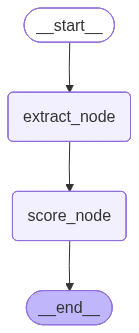

In [226]:
final_graph

In [227]:
loaded_docs[0].page_content

'Atul Khiyani \n📧 atulkhiyani09@gmail.com| 📞 +91-9243962800  | \n GitHub  |  \n LinkedIn |  LeetCode \nProfile Summary \nResults-driven Full-Stack Developer specializing in JavaScript, TypeScript, and Next.js. Experienced in \narchitecting scalable applications with robust authentication (RBAC, JWT) and real-time systems. \nPassionate about systems engineering, DevOps, and building production-ready software. \nTechnical Skills \n  Languages: TypeScript, JavaScript, Java \n  Frontend: Next.js, React.js, Zustand, Tailwind CSS \n  Backend: Node.js, Express.js, WebSockets (Socket.IO), Server Actions \n  Database & DevOps: PostgreSQL, MongoDB, Prisma ORM, Docker, Redis, Git \n \n \nEXPERIENCE \nApaxion Technology | Software Engineer Intern (Remote) | Oct 2025 – Present \nArchitecting and developing scalable web solutions. improving application performance and type safety. \n \nProjects \nCode Gladiator (Remote Code Execution Engine) | Next.js, Node.js, Docker, Redis, WebSockets \n\uf0b7 \nR

In [ ]:
final_graph.invoke({'resume_content_raw':loaded_docs[0].page_content})

<coroutine object Pregel.ainvoke at 0x000001E66CA5EF80>

In [290]:
class JD_Structured(BaseModel):
    skills: list[str] = Field(..., description='Skills required mentioned in JD')
    experience: str = Field(description='Experience required mentioned in JD')
    title: str = Field(..., description='This refers to the job title')
    Location: str = Field(..., description='Location of the Job. If flexible, state both remote and onsite. Clearly specify if Remote or Onsite.')
    summary: str = Field(..., description='Summary of the Job, not more than 3-4 lines')
    soft_skills: list[str] = Field(description='Any Soft Skill mentioned in the JD')
    salary_range: str = Field(description='The salary range or compensation details if mentioned in the JD. Return "Not specified" if absent.')
    perks_benefits: list[str] = Field(description='List of any benefits, perks, or "what we offer" details mentioned in the JD')

In [315]:
class JDMatcher(TypedDict):
    raw_jd_content: str
    raw_resume_content:str
    parsed_resume_structured: Resume_Details
    parsed_jd_structured:JD_Structured
    missing_points: list[str]         
    points_matched: list[str]        
    improvements: list[ImprovementSuggestion]  

In [316]:
def jd_analyzer(state:JDMatcher):
    raw_jd = state['raw_jd_content']

    prompt = ChatPromptTemplate.from_messages([
        ("system","You are an expert Technical Recruiter and Data Extraction Specialist. Your task is to carefully analyze the provided Job Description (JD) text and extract the key information into a highly structured format. Adhere strictly to these rules: No Hallucinations: Only extract information explicitly mentioned in the text. If a detail like salary range, experience, or perks is missing, explicitly output 'Not specified'. Do not guess. Comprehensive Skills: Exhaustively list all hard skills (programming languages, frameworks, databases, tools) and soft skills (communication, leadership, etc.). If it is listed as a 'nice-to-have', include it. Clear Summarization: Write a concise 3-4 line summary of the role's primary focus and daily responsibilities. Precise Location: Clearly state if the role is Remote, Onsite, or Hybrid/Flexible based on the text provided. Perks & Benefits: Extract any specific offerings, bonuses, or cultural benefits into a clean list."),
        ("human","JD Content {details}")
    ])

    chain = prompt | llm.with_structured_output(JD_Structured)

    result = chain.invoke({"details":raw_jd})

    return {"parsed_jd_structured":result}

In [317]:
def resume_extract(state: JDMatcher):
  
    raw_content = state['raw_resume_content']
    
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an expert Applicant Tracking System (ATS) data extraction specialist. Your task is to carefully analyze the provided resume details and accurately find or extract the specific information requested by the user. Adhere strictly to these rules: Never Hallucinate: Only extract information that is explicitly stated in the provided resume text. Missing Data: If the requested information is not present in the resume, you must explicitly state 'Information not found in the provided text.' Do not guess or infer. Format: Keep your answers concise, direct, and structured. Do not include unnecessary conversational filler."),
        ("human", "Resume Details: {details}") 
    ])

    chain = prompt | llm.with_structured_output(Resume_Details)

    result = chain.invoke({'details': raw_content})

    
    return {"parsed_resume_structured": result}


In [330]:
class Matcher(BaseModel):
    points_matched: list[str]
    missing_points: list[str]
    summary_suggestion: str = Field(description="A rewritten high-impact summary")
    experience_suggestions: list[str] = Field(description="Rewrites for work history")
    project_suggestions: list[str] = Field(description="Rewrites for projects")
    skills_strategy: str = Field(description="How to reorder the skills section")

In [331]:
def evaluator_node(state:JDMatcher):
    parsed_jd = state['parsed_jd_structured']
    parsed_resume = state['parsed_resume_structured']

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a World-Class Technical Recruiter and ATS Optimization Expert. Your mission is to perform a surgical-level gap analysis and provide a complete blueprint for tailoring a candidate's resume to a specific Job Description (JD).

You are provided with structured JSON data for both the JD and the Resume. Your analysis must be ruthless, objective, and highly tactical.

ADHERE TO THESE RED-LINE RULES:
1. NO HALLUCINATION: Do not invent experiences. Only suggest optimizations based on the candidate's existing projects and roles.
2. ATS SCORING LOGIC: Prioritize hard skills and job titles. If the JD asks for 'Senior Full Stack Developer' and the resume says 'Software Engineer Intern', flag this as a critical structural gap.
3. QUANTIFIED IMPACT: Every suggestion for Experience or Projects MUST include a placeholder for a metric (e.g., [X%], [Y ms], [Z users]).

PROVIDE FEEDBACK ACROSS THESE 5 PILLARS:

PILLAR 1: KEYWORD MATCHING (points_matched & missing_points)
- Extract a list of direct hits and direct misses. 
- If a skill is 'conceptually' present but named differently (e.g., JD asks for 'Cloud Native' and user has 'Docker/K8s'), list it as a match but suggest using the JD's exact terminology.

PILLAR 2: EXECUTIVE SUMMARY OVERHAUL
- Rewrite the candidate's 'Summary' to act as a direct mirror to the JD's 'About Us' and 'Responsibilities'. 
- It should highlight the top 3 overlapping tech stacks immediately.

PILLAR 3: EXPERIENCE & IMPACT ALIGNMENT
- Analyze the 'Experience' section. For each role, provide a suggested rewrite for the most relevant bullet point.
- Target the JD's primary responsibilities. (e.g., If the JD emphasizes 'System Design', suggest a bullet point that focuses on the architectural decisions made during their internship).

PILLAR 4: PROJECT RELEVANCE (The 'Hook')
- Pick the top 2 projects from the resume that best align with the JD's tech stack.
- Suggest how to re-order or re-phrase project descriptions to put the JD's required tools (e.g., Supabase, Python) at the very beginning of the sentence.

PILLAR 5: SKILLS REORGANIZATION
- Suggest the 'Optimal Skills Layout'. Tell the candidate which skills to 'Promote' to the top of their list and which to 'Demote' based on the JD's 'Must-haves'."""),
        
        ("human", "Job Description Data:\n{jd_details}\n\nCandidate Resume Data:\n{resume_details}")
    ])
    
    chain = prompt | llm.with_structured_output(Matcher)

    result = chain.invoke({"jd_details":parsed_jd.model_dump_json(),"resume_details":parsed_resume.model_dump_json()})

    return {
        "points_matched": result.points_matched,
        "missing_points": result.missing_points,
        "improvements": result.improvements
    }


In [332]:
graph = StateGraph(state_schema=JDMatcher)

graph.add_node('jd_analyzer',jd_analyzer)
graph.add_node('resume_extract',resume_extract)
graph.add_node('evaluator_node',evaluator_node)

graph.add_edge(START,"jd_analyzer")
graph.add_edge(START,"resume_extract")

graph.add_edge("jd_analyzer","evaluator_node")
graph.add_edge("resume_extract","evaluator_node")

graph.add_edge("evaluator_node",END)

final_graph2 = graph.compile()

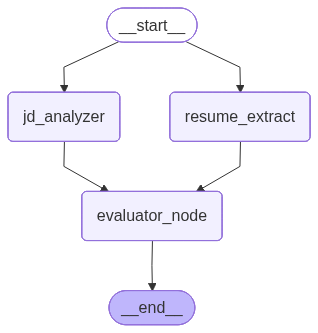

In [333]:
final_graph2

In [ ]:
my_resume_text = """Atul Khiyani 
📧 atulkhiyani09@gmail.com | 📞 +91-9243962800 | GitHub | LinkedIn | LeetCode 
Profile Summary 
Results-driven Full-Stack Developer specializing in JavaScript, TypeScript, and Next.js. Experienced in architecting scalable applications with robust authentication (RBAC, JWT) and real-time systems. Passionate about systems engineering, DevOps, and building production-ready software. 
Technical Skills 
Languages: TypeScript, JavaScript, Java 
Frontend: Next.js, React.js, Zustand, Tailwind CSS 
Backend: Node.js, Express.js, WebSockets (Socket.IO), Server Actions 
Database & DevOps: PostgreSQL, MongoDB, Prisma ORM, Docker, Redis, Git 
EXPERIENCE 
Apaxion Technology | Software Engineer Intern (Remote) | Oct 2025 – Present 
Architecting and developing scalable web solutions. improving application performance and type safety. 
Projects 
Code Gladiator (Remote Code Execution Engine) | Next.js, Node.js, Docker, Redis, WebSockets 
- Remote Code Execution: Built a secure, high-performance execution engine capable of running untrusted code in C++, Java, Python, and JS. 
- Sandboxed Architecture: Engineered a Docker-based isolation strategy where every submission runs in an ephemeral container, ensuring 100% system security. 
- Real-Time Battle Mode: Designed an Event-Driven Architecture using Redis Queues and Pub/Sub to handle asynchronous execution and broadcast results instantly via WebSockets. 
- Custom Language Drivers: Developed dynamic code generators to inject input parsing logic, enabling cross-language output normalization (JSON). 
RBAC Dashboard (Access Control System) | Next.js 14, PostgreSQL, Prisma, OpenAI API 
- AI-Driven Permission System: Engineered a granular RBAC matrix featuring an AI assistant that translates natural language prompts into precise database permission sets. 
- High-Performance UX: Implemented Optimistic UI patterns to provide zero-latency feedback during permission updates, ensuring a seamless administrative experience. 
- Modern Server Architecture: Leveraged Next.js 14 Server Actions to handle data mutations directly from server components, reducing API boilerplate by 40% while maintaining type safety. 
ACHIEVEMENTS 
- 6th Place out of 639+ teams at NIT Patna Hackathon. 
- Finalist at hackathons hosted by IIIT Delhi and IIIT Gwalior. 
EDUCATION 
Madhav Institute of Technology and Science | Gwalior, India Bachelor of Technology (Computer Science) | 2023 – 2027 | CGPA: 8.00"""

target_jd_text = """We are looking for a strong Full-Stack Developer to execute product features and contribute to our core platform development. 
Responsibilities
- Implement frontend features using TypeScript
- Develop backend services and APIs using Supabase / PostgreSQL
- Contribute to our Python-based AI & analytics engine (data logic, integrations)
- Write and optimize SQL queries and database logic
Tech Stack
- Core Language: TypeScript
- Backend & Database: Supabase (PostgreSQL), PL/pgSQL
- AI Layer: Python
- Frontend & CMS: TypeScript, Webflow, Weglot API
- Infrastructure: Vercel / Netlify
- CI/CD: GitHub Actions
Requirements
- Experience as a Full-Stack Developer (3+ years)
- Strong knowledge of TypeScript / JavaScript
- Solid experience with Python in backend, data, or analytics contexts
- Good understanding of PostgreSQL and data modeling"""

inputs = {
    "raw_jd_content": target_jd_text,
    "raw_resume_content": my_resume_text
}


print("🧠 Analyzing Resume against Job Description...")
results = final_graph2.invoke(inputs)

print(results)

In [228]:
class ResumeRequest(BaseModel):
    resume_text: str

In [ ]:
@app.post("/api/analyze-resume")
async def analyze_resume_endpoint(request: ResumeRequest):
    
   
    initial_state = {
        "resume_content_raw": request.resume_text
    }
    
 
    result = final_graph.ainvoke(initial_state)
    

    return {
        "score": result.get("final_score"),
        "suggestions": result.get("suggestions")
    }


@app.get('/test')
async def test_server():
    return {
        "success":True,
        "message":"Server is Running"
    }


In [ ]:
config = uvicorn.Config(app, host="0.0.0.0", port=8000)
server = uvicorn.Server(config)


await server.serve()